# Classifying Penguins with Keras

In [25]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

In [26]:
#! pip install palmerpenguins
from palmerpenguins import load_penguins
penguins = load_penguins()
penguins.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [40]:
penguins = penguins.dropna()
penguins.shape

(333, 8)

In [41]:
penguins_x = pd.concat([penguins[['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']], pd.get_dummies(penguins['sex'])], axis = 1)
# penguins_x = penguins_x[['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'female', 'male']]
penguins_x

,body_mass_g,bill_length_mm,bill_depth_mm,flipper_length_mm,female,male
0,3750.0,39.1,18.7,181.0,False,True
1,3800.0,39.5,17.4,186.0,True,False
2,3250.0,40.3,18.0,195.0,True,False
4,3450.0,36.7,19.3,193.0,True,False
5,3650.0,39.3,20.6,190.0,False,True
...,...,...,...,...,...,...
339,4000.0,55.8,19.8,207.0,False,True
340,3400.0,43.5,18.1,202.0,True,False
341,3775.0,49.6,18.2,193.0,False,True
342,4100.0,50.8,19.0,210.0,False,True


In [42]:
x = penguins_x.values
min_max_scaler = StandardScaler()
scaled_penguins_x = pd.DataFrame(min_max_scaler.fit_transform(x), columns=penguins_x.columns)
scaled_penguins_x

,body_mass_g,bill_length_mm,bill_depth_mm,flipper_length_mm,female,male
0,-0.568475,-0.896042,0.780732,-1.426752,-0.991031,0.991031
1,-0.506286,-0.822788,0.119584,-1.069474,1.009050,-1.009050
2,-1.190361,-0.676280,0.424729,-0.426373,1.009050,-1.009050
3,-0.941606,-1.335566,1.085877,-0.569284,1.009050,-1.009050
4,-0.692852,-0.859415,1.747026,-0.783651,-0.991031,0.991031
...,...,...,...,...,...,...
328,-0.257532,2.162314,1.340165,0.431094,-0.991031,0.991031
329,-1.003795,-0.090248,0.475587,0.073816,1.009050,-1.009050
330,-0.537380,1.026876,0.526444,-0.569284,-0.991031,0.991031
331,-0.133155,1.246638,0.933305,0.645461,-0.991031,0.991031


In [43]:
penguins_y = penguins['species']
print(penguins_y)
penguins_y = penguins_y.astype('category').cat.codes.to_numpy()
penguins_y

0         Adelie
1         Adelie
2         Adelie
4         Adelie
5         Adelie
         ...    
339    Chinstrap
340    Chinstrap
341    Chinstrap
342    Chinstrap
343    Chinstrap
Name: species, Length: 333, dtype: object


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [44]:
#construct the model
inputs = keras.Input(shape=(6,))
x = layers.Dense(7, activation = 'relu')(inputs)
x = layers.Dense(5, activation = 'relu')(x)
x = layers.Dense(3, activation = 'relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model")

In [45]:
model.summary()

Model: "penguin_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 7)              │            49 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 5)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 3)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119 (476.00 B)

 Trainable params: 119 (476.00 B)

 Non-trainable params: 0 (0.00 B)

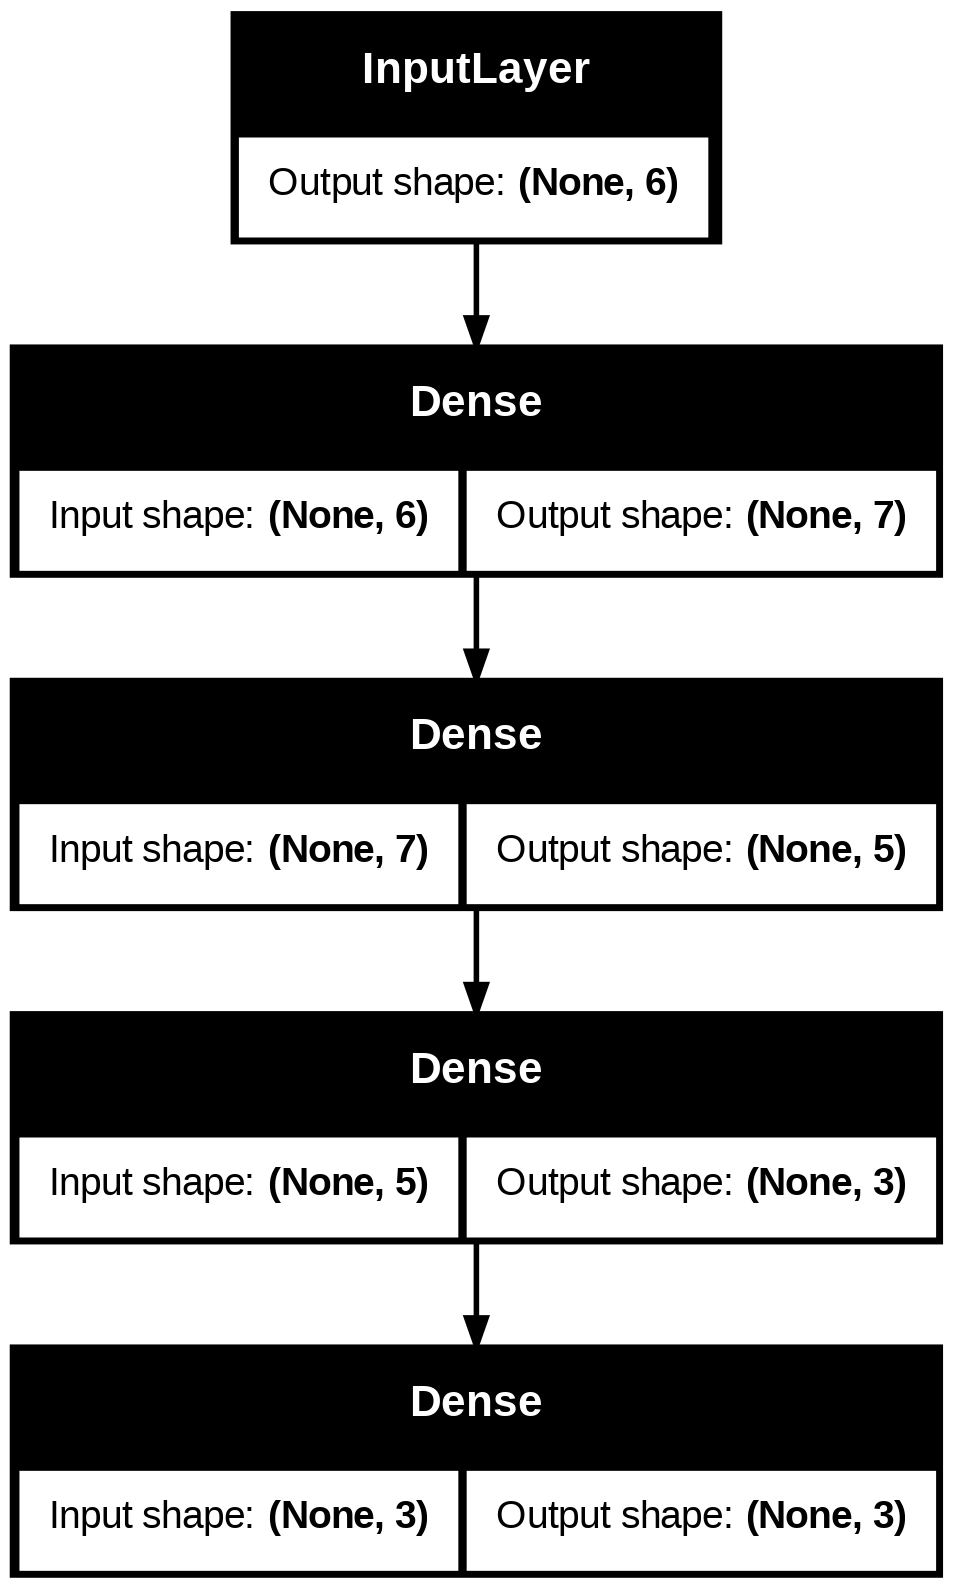

In [46]:
keras.utils.plot_model(model, show_shapes = True)

In [47]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=keras.optimizers.RMSprop(),
    metrics=["accuracy"],
)

history = model.fit(scaled_penguins_x, penguins_y, batch_size = 64, epochs=100, validation_split=0.1)

scores = model.evaluate(scaled_penguins_x, penguins_y, verbose=2)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:1214: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.3946 - loss: 1.0712 - val_accuracy: 0.0000e+00 - val_loss: 1.1577
Epoch 2/100
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3281 - loss: 1.0856

/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:1214: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3645 - loss: 1.0446 - val_accuracy: 0.0000e+00 - val_loss: 1.1683
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3846 - loss: 1.0256 - val_accuracy: 0.0000e+00 - val_loss: 1.1770
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4247 - loss: 1.0088 - val_accuracy: 0.0000e+00 - val_loss: 1.1892
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4448 - loss: 0.9943 - val_accuracy: 0.0000e+00 - val_loss: 1.2022
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4749 - loss: 0.9811 - val_accuracy: 0.0000e+00 - val_loss: 1.2140
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5518 - loss: 0.9681 - val_accuracy: 0.0000e+00 - val_loss: 1.2254
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6120 - loss: 0.9562 - val_accuracy: 0.0000e+00 - val_loss: 1.2351
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6488 - loss: 0.9446 - val_accuracy: 0.

In [48]:
model_logit_true = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model_scaled")

model_logit_true.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.RMSprop(),
    metrics=["accuracy"],
)

history_logit_true = model_logit_true.fit(scaled_penguins_x, penguins_y, batch_size = 64, epochs = 100, validation_split = 0.1)

scores = model_logit_true.evaluate(scaled_penguins_x, penguins_y, verbose = 2)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.9833 - loss: 0.3132 - val_accuracy: 1.0000 - val_loss: 0.1820
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9900 - loss: 0.3078 - val_accuracy: 1.0000 - val_loss: 0.1705
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9866 - loss: 0.3043 - val_accuracy: 1.0000 - val_loss: 0.1688
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9900 - loss: 0.3014 - val_accuracy: 1.0000 - val_loss: 0.1622
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9900 - loss: 0.2984 - val_accuracy: 1.0000 - val_loss: 0.1556
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9900 - loss: 0.2955 - val_accuracy: 1.0000 - val_loss: 0.1533
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9900 - loss: 0.2928 - val_accuracy: 1.0000 - val_loss: 0.1493
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9900 - loss: 0.2900 - val_accuracy: 1.0000 - val_loss:

In [49]:
model_logit_true.predict(scaled_penguins_x)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


array([[7.76775181e-01, 1.09578930e-01, 1.13645926e-01],
       [7.76775181e-01, 1.09578930e-01, 1.13645926e-01],
       [7.76775181e-01, 1.09578930e-01, 1.13645926e-01],
       [7.76775181e-01, 1.09578930e-01, 1.13645926e-01],
       [7.76775181e-01, 1.09578930e-01, 1.13645926e-01],
       [7.76775181e-01, 1.09578930e-01, 1.13645926e-01],
       [7.76775181e-01, 1.09578930e-01, 1.13645926e-01],
       [7.10242987e-01, 2.00605333e-01, 8.91516954e-02],
       [7.76775181e-01, 1.09578930e-01, 1.13645926e-01],
       [7.76775181e-01, 1.09578930e-01, 1.13645926e-01],
       [7.76775181e-01, 1.09578930e-01, 1.13645926e-01],
       [7.76775181e-01, 1.09578930e-01, 1.13645926e-01],
       [7.76775181e-01, 1.09578930e-01, 1.13645926e-01],
       [7.76775181e-01, 1.09578930e-01, 1.13645926e-01],
       [7.76775181e-01, 1.09578930e-01, 1.13645926e-01],
       [7.76775181e-01, 1.09578930e-01, 1.13645926e-01],
       [7.76775181e-01, 1.09578930e-01, 1.13645926e-01],
       [7.76775181e-01, 1.09578

In [50]:
penguins['species']

,species
0,Adelie
1,Adelie
2,Adelie
4,Adelie
5,Adelie
...,...
339,Chinstrap
340,Chinstrap
341,Chinstrap
342,Chinstrap


In [51]:
penguins_y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [53]:
model_logit_false = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model_scaled")

model_logit_false.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.RMSprop(),
    metrics=["accuracy"],
)

history_logit_false = model_logit_false.fit(scaled_penguins_x, penguins_y, batch_size = 64, epochs = 100, validation_split = 0.1)

scores = model_logit_false.evaluate(scaled_penguins_x, penguins_y, verbose = 2)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 1.0000 - loss: 0.0746 - val_accuracy: 1.0000 - val_loss: 0.0091
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0734 - val_accuracy: 1.0000 - val_loss: 0.0080
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 1.0000 - loss: 0.0724 - val_accuracy: 1.0000 - val_loss: 0.0087
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.0718 - val_accuracy: 1.0000 - val_loss: 0.0092
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.0709 - val_accuracy: 1.0000 - val_loss: 0.0087
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0703 - val_accuracy: 1.0000 - val_loss: 0.0086
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.0695 - val_accuracy: 1.0000 - val_loss: 0.0095
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 0.0690 - val_accuracy: 1.0000 - val_loss:

In [54]:
model_logit_false.predict(scaled_penguins_x)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


array([[9.44148898e-01, 2.74800994e-02, 2.83708852e-02],
       [9.44148898e-01, 2.74800994e-02, 2.83708852e-02],
       [9.44148898e-01, 2.74800994e-02, 2.83708852e-02],
       [9.44148898e-01, 2.74800994e-02, 2.83708852e-02],
       [9.44148898e-01, 2.74800994e-02, 2.83708852e-02],
       [9.44148898e-01, 2.74800994e-02, 2.83708852e-02],
       [9.44148898e-01, 2.74800994e-02, 2.83708852e-02],
       [9.10209179e-01, 6.63886145e-02, 2.34022141e-02],
       [9.44148898e-01, 2.74800994e-02, 2.83708852e-02],
       [9.44148898e-01, 2.74800994e-02, 2.83708852e-02],
       [9.44148898e-01, 2.74800994e-02, 2.83708852e-02],
       [9.44148898e-01, 2.74800994e-02, 2.83708852e-02],
       [9.44148898e-01, 2.74800994e-02, 2.83708852e-02],
       [9.44148898e-01, 2.74800994e-02, 2.83708852e-02],
       [9.44148898e-01, 2.74800994e-02, 2.83708852e-02],
       [9.44148898e-01, 2.74800994e-02, 2.83708852e-02],
       [9.44148898e-01, 2.74800994e-02, 2.83708852e-02],
       [9.44148898e-01, 2.74800

In [55]:
model_logit_false.predict(scaled_penguins_x)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


array([[9.44148898e-01, 2.74800994e-02, 2.83708852e-02],
       [9.44148898e-01, 2.74800994e-02, 2.83708852e-02],
       [9.44148898e-01, 2.74800994e-02, 2.83708852e-02],
       [9.44148898e-01, 2.74800994e-02, 2.83708852e-02],
       [9.44148898e-01, 2.74800994e-02, 2.83708852e-02],
       [9.44148898e-01, 2.74800994e-02, 2.83708852e-02],
       [9.44148898e-01, 2.74800994e-02, 2.83708852e-02],
       [9.10209179e-01, 6.63886145e-02, 2.34022141e-02],
       [9.44148898e-01, 2.74800994e-02, 2.83708852e-02],
       [9.44148898e-01, 2.74800994e-02, 2.83708852e-02],
       [9.44148898e-01, 2.74800994e-02, 2.83708852e-02],
       [9.44148898e-01, 2.74800994e-02, 2.83708852e-02],
       [9.44148898e-01, 2.74800994e-02, 2.83708852e-02],
       [9.44148898e-01, 2.74800994e-02, 2.83708852e-02],
       [9.44148898e-01, 2.74800994e-02, 2.83708852e-02],
       [9.44148898e-01, 2.74800994e-02, 2.83708852e-02],
       [9.44148898e-01, 2.74800994e-02, 2.83708852e-02],
       [9.44148898e-01, 2.74800

In [56]:
penguins_y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [58]:
from sklearn.metrics import accuracy_score
import numpy as np

# Get predictions from model_logit_false
predictions_false = model_logit_false.predict(scaled_penguins_x)
predicted_classes_false = np.argmax(predictions_false, axis=1)

# Get predictions from model_logit_true
predictions_true = model_logit_true.predict(scaled_penguins_x)
predicted_classes_true = np.argmax(predictions_true, axis=1)

# Calculate and print accuracy for model_logit_false
accuracy_false = accuracy_score(penguins_y, predicted_classes_false)
print(f"Accuracy for model_logit_false: {accuracy_false:.4f}")

# Calculate and print accuracy for model_logit_true
accuracy_true = accuracy_score(penguins_y, predicted_classes_true)
print(f"Accuracy for model_logit_true: {accuracy_true:.4f}")

print("\n--- Comparison ---")
if accuracy_false > accuracy_true:
    print("model_logit_false has higher accuracy.")
elif accuracy_true > accuracy_false:
    print("model_logit_true has higher accuracy.")
else:
    print("Both models have the same accuracy.")

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Accuracy for model_logit_false: 1.0000
Accuracy for model_logit_true: 1.0000

--- Comparison ---
Both models have the same accuracy.


In [59]:
# 1. Implement a proper train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(scaled_penguins_x, penguins_y, test_size=0.2, random_state=42, stratify=penguins_y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (266, 6)
X_test shape: (67, 6)
y_train shape: (266,)
y_test shape: (67,)


### Independent Model Definitions and Training

In [60]:
# 2. Redefine model_logit_true with fresh weights
# The original inputs and outputs (from cell 5A35n0kL3Fqs) are still in scope, but we need to create a new model instance.
# For a true fresh model, you would re-declare inputs and outputs here.
# For now, let's reuse inputs/outputs but create a NEW model instance.

# Reconstruct the model architecture for model_logit_true
inputs_true = keras.Input(shape=(6,))
x_true = layers.Dense(7, activation = 'relu')(inputs_true)
x_true = layers.Dense(5, activation = 'relu')(x_true)
x_true = layers.Dense(3, activation = 'relu')(x_true)
outputs_true = layers.Dense(3, activation='softmax')(x_true)

model_logit_true_new = keras.Model(inputs=inputs_true, outputs=outputs_true, name="penguin_model_true_new")

model_logit_true_new.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False), # As per advice
    optimizer=keras.optimizers.RMSprop(),
    metrics=["accuracy"],
)

print("\n--- Training model_logit_true_new ---")
history_logit_true_new = model_logit_true_new.fit(X_train, y_train, batch_size = 64, epochs = 100, validation_data=(X_test, y_test))

print("\n--- Evaluating model_logit_true_new on Test Set ---")
scores_true_new = model_logit_true_new.evaluate(X_test, y_test, verbose = 2)


--- Training model_logit_true_new ---
Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.4398 - loss: 1.1268 - val_accuracy: 0.4328 - val_loss: 1.1113
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4323 - loss: 1.1044 - val_accuracy: 0.4328 - val_loss: 1.0969
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4398 - loss: 1.0913 - val_accuracy: 0.4328 - val_loss: 1.0844
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4398 - loss: 1.0790 - val_accuracy: 0.4328 - val_loss: 1.0738
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4361 - loss: 1.0683 - val_accuracy: 0.4328 - val_loss: 1.0634
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4398 - loss: 1.0579 - val_accuracy: 0.4328 - val_loss: 1.0530
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4474 - loss: 1.0477 - val_accuracy: 0.4627 - val_loss: 1.0430
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4624 - loss: 1.

In [63]:
# 2. Redefine model_logit_false with fresh weights

# Reconstruct the model architecture for model_logit_false
inputs_false = keras.Input(shape=(6,))
x_false = layers.Dense(7, activation = 'relu')(inputs_false)
x_false = layers.Dense(5, activation = 'relu')(x_false)
x_false = layers.Dense(3, activation = 'relu')(x_false)
outputs_false = layers.Dense(3, activation='softmax')(x_false)

model_logit_false_new = keras.Model(inputs=inputs_false, outputs=outputs_false, name="penguin_model_false_new")

model_logit_false_new.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False), # As per original intent/advice if this model was designed for logits
    optimizer=keras.optimizers.RMSprop(),
    metrics=["accuracy"],
)

print("\n--- Training model_logit_false_new ---")
history_logit_false_new = model_logit_false_new.fit(X_train, y_train, batch_size = 64, epochs = 100, validation_data=(X_test, y_test))

print("\n--- Evaluating model_logit_false_new on Test Set ---")
scores_false_new = model_logit_false_new.evaluate(X_test, y_test, verbose = 2)


--- Training model_logit_false_new ---
Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.1992 - loss: 1.1344 - val_accuracy: 0.2090 - val_loss: 1.1422
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2030 - loss: 1.1234 - val_accuracy: 0.2090 - val_loss: 1.1317
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.2105 - loss: 1.1152 - val_accuracy: 0.2836 - val_loss: 1.1213
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2556 - loss: 1.1080 - val_accuracy: 0.3134 - val_loss: 1.1154
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2744 - loss: 1.1021 - val_accuracy: 0.3284 - val_loss: 1.1097
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2895 - loss: 1.0960 - val_accuracy: 0.3731 - val_loss: 1.1033
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3120 - loss: 1.0900 - val_accuracy: 0.3582 - val_loss: 1.0952
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3684 - loss: 

### Compare Accuracies of the Corrected Models

In [64]:
from sklearn.metrics import accuracy_score
import numpy as np

# Get predictions from model_logit_true_new
predictions_true_new = model_logit_true_new.predict(X_test)
predicted_classes_true_new = np.argmax(predictions_true_new, axis=1)

# Get predictions from model_logit_false_new
predictions_false_new = model_logit_false_new.predict(X_test)
predicted_classes_false_new = np.argmax(predictions_false_new, axis=1)

# Calculate and print accuracy for model_logit_true_new
accuracy_true_new = accuracy_score(y_test, predicted_classes_true_new)
print(f"Accuracy for model_logit_true (from_logits=False) on Test Set: {accuracy_true_new:.4f}")

# Calculate and print accuracy for model_logit_false_new
accuracy_false_new = accuracy_score(y_test, predicted_classes_false_new)
print(f"Accuracy for model_logit_false (from_logits=True) on Test Set: {accuracy_false_new:.4f}")

print("\n--- Corrected Model Comparison on Test Set ---")
if accuracy_false_new > accuracy_true_new:
    print("model_logit_false_new has higher accuracy.")
elif accuracy_true_new > accuracy_false_new:
    print("model_logit_true_new has higher accuracy.")
else:
    print("Both new models have the same accuracy.")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Accuracy for model_logit_true (from_logits=False) on Test Set: 0.9104
Accuracy for model_logit_false (from_logits=True) on Test Set: 0.7910

--- Corrected Model Comparison on Test Set ---
model_logit_true_new has higher accuracy.


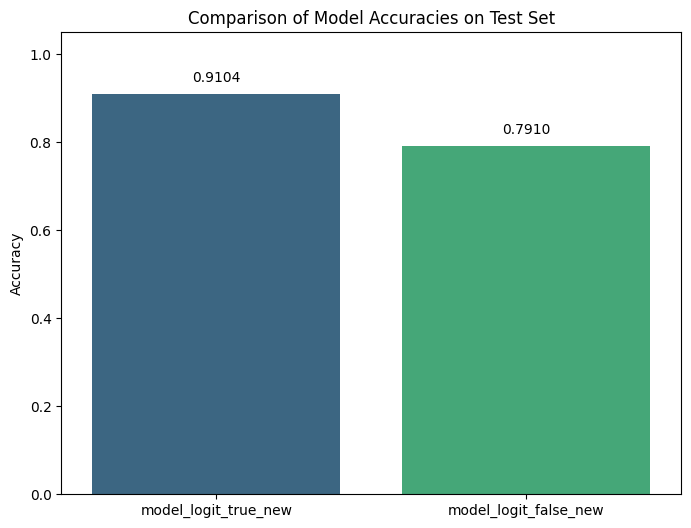

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for accuracy comparison
model_names = ['model_logit_true_new', 'model_logit_false_new']
accuracies = [accuracy_true_new, accuracy_false_new]

plt.figure(figsize=(8, 6))
sns.barplot(x=model_names, y=accuracies, hue=model_names, palette='viridis', legend=False)
plt.title('Comparison of Model Accuracies on Test Set')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05) # Set y-axis limit for better comparison
for index, value in enumerate(accuracies):
    plt.text(index, value + 0.02, f'{value:.4f}', ha='center', va='bottom')
plt.show()

### Training History Comparison

Let's visualize the training and validation loss and accuracy over epochs for both models.

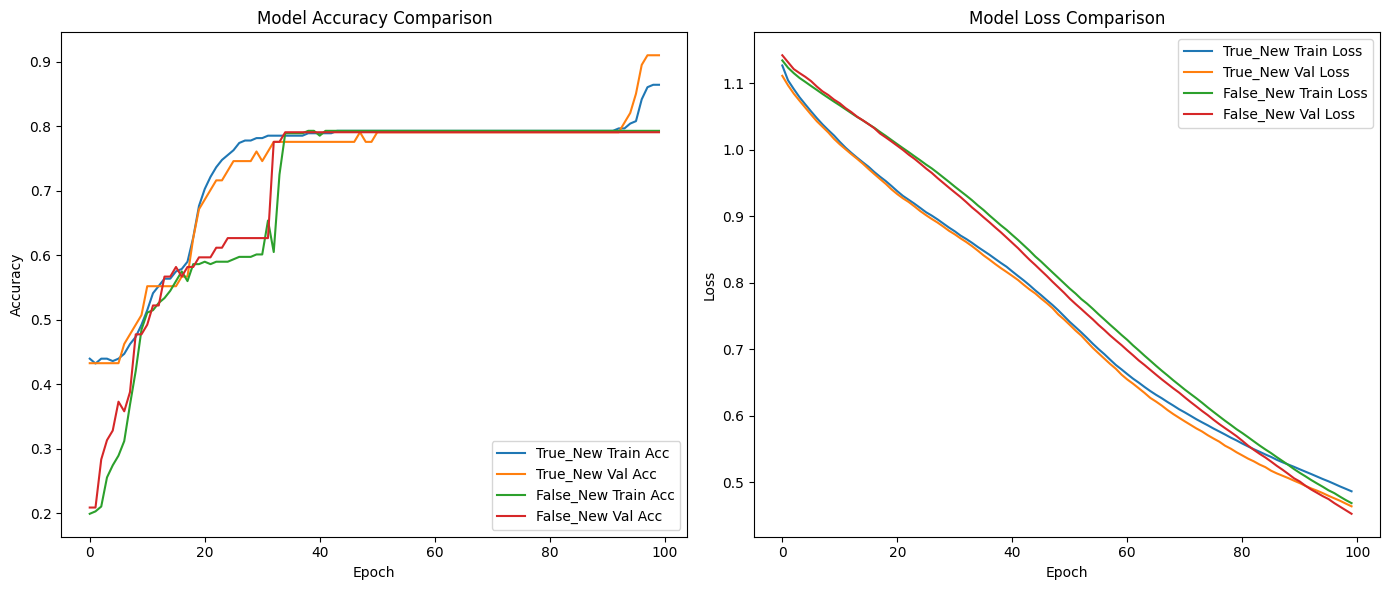

In [66]:
# Plot training & validation accuracy values
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(history_logit_true_new.history['accuracy'], label='True_New Train Acc')
plt.plot(history_logit_true_new.history['val_accuracy'], label='True_New Val Acc')
plt.plot(history_logit_false_new.history['accuracy'], label='False_New Train Acc')
plt.plot(history_logit_false_new.history['val_accuracy'], label='False_New Val Acc')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_logit_true_new.history['loss'], label='True_New Train Loss')
plt.plot(history_logit_true_new.history['val_loss'], label='True_New Val Loss')
plt.plot(history_logit_false_new.history['loss'], label='False_New Train Loss')
plt.plot(history_logit_false_new.history['val_loss'], label='False_New Val Loss')
plt.title('Model Loss Comparison')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()